Function for Loading the Dataset

# CNN From Scratch: Mathematical Roadmap

This notebook builds a small CNN for MNIST using only Python lists and math. The forward pass is:

$$x \rightarrow \text{Conv} \rightarrow \text{ReLU} \rightarrow \text{MaxPool} \rightarrow \text{Flatten} \rightarrow \text{Dense} \rightarrow \text{Softmax} \rightarrow L$$

Training sends gradients backward in the reverse order:

$$\frac{\partial L}{\partial z} \rightarrow \frac{\partial L}{\partial W_{dense}} \rightarrow \frac{\partial L}{\partial \text{pool}} \rightarrow \frac{\partial L}{\partial \text{conv}} \rightarrow \frac{\partial L}{\partial W_{conv}}$$

Each learnable parameter is updated with SGD:

$$w := w - \eta \frac{\partial L}{\partial w}$$

where $\eta$ is the learning rate.


## Data Loading And Normalization

MNIST images are stored as binary IDX files. Each image has $28 \times 28 = 784$ pixels.

The loader reads the file header to get the number of images, rows, and columns. Then every pixel is normalized from $[0,255]$ to $[0,1]$:

$$x_{norm} = \frac{x}{255}$$

At first, each image is a flat vector:

$$x \in \mathbb{R}^{784}$$

The label is one integer class:

$$y \in \{0,1,2,3,4,5,6,7,8,9\}$$


## Reshaping And Channel Dimension

A CNN needs spatial structure, so the flat image is reshaped:

$$784 \rightarrow 28 \times 28$$

The flat index for row $r$ and column $c$ is:

$$\text{index} = r \cdot 28 + c$$

Then one channel is added because MNIST is grayscale:

$$28 \times 28 \rightarrow 1 \times 28 \times 28$$

The indexing convention becomes:

$$x[\text{channel}][\text{row}][\text{column}]$$

An RGB image would have 3 channels, but MNIST has only 1.


## Convolution Layer

A filter is a small learnable kernel. In this notebook each filter has shape:

$$1 \times 3 \times 3$$

With 8 filters, the full filter tensor is:

$$8 \times 1 \times 3 \times 3$$

For one filter, one output value is computed by sliding the kernel over the image:

$$z_{i,j} = b + \sum_c \sum_{u=0}^{K-1} \sum_{v=0}^{K-1} x_{c,i+u,j+v} w_{c,u,v}$$

Because there is no padding and $K=3$:

$$28 - 3 + 1 = 26$$

So the convolution output shape is:

$$1 \times 28 \times 28 \rightarrow 8 \times 26 \times 26$$


## ReLU And Max Pooling

ReLU adds non-linearity:

$$\text{ReLU}(z) = \max(0,z)$$

Negative values become 0 and positive values pass through unchanged. The shape stays the same:

$$8 \times 26 \times 26 \rightarrow 8 \times 26 \times 26$$

Max pooling keeps the strongest activation in each $2 \times 2$ region:

$$p_{i,j} = \max \{x_{2i,2j}, x_{2i,2j+1}, x_{2i+1,2j}, x_{2i+1,2j+1}\}$$

With pool size 2 and stride 2:

$$8 \times 26 \times 26 \rightarrow 8 \times 13 \times 13$$


## Flatten, Dense Layer, Softmax, And Loss

Flatten converts the pooled feature maps into one vector:

$$8 \times 13 \times 13 = 1352$$

The dense layer maps 1352 features to 10 digit scores, called logits:

$$z_k = b_k + \sum_i x_i W_{k,i}$$

Softmax converts logits into probabilities:

$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

Cross-entropy loss for correct label $y$ is:

$$L = -\log(p_y)$$

High probability on the correct class means low loss. Low probability on the correct class means high loss.


## Softmax/Cross-Entropy Backward And Dense Backward

For softmax followed by cross-entropy, the gradient simplifies to:

$$\frac{\partial L}{\partial z_k} = p_k - y_k$$

where $y_k$ is 1 for the correct class and 0 otherwise.

For the dense layer:

$$z = \sum_i x_i w_i + b$$

The gradients are:

$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial z} x_i$$

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial z}$$

$$\frac{\partial L}{\partial x_i} = \frac{\partial L}{\partial z} w_i$$


## Flatten Backward, MaxPool Backward, And ReLU Backward

Flatten backward reshapes the gradient back to the pooled shape:

$$1352 \rightarrow 8 \times 13 \times 13$$

MaxPool backward sends each gradient only to the location that won the max operation. If the forward block was:

$$\begin{bmatrix}1 & 5 \\ 2 & 3\end{bmatrix}$$

then the gradient goes only to the position of 5:

$$\begin{bmatrix}0 & g \\ 0 & 0\end{bmatrix}$$

ReLU backward uses:

$$\frac{d}{dz}\text{ReLU}(z) = \begin{cases}1, & z > 0 \\ 0, & z \le 0\end{cases}$$

So gradients pass through only where the original convolution output was positive.


## Convolution Backward And Parameter Updates

The forward convolution equation was:

$$z_{i,j} = b + \sum_c \sum_u \sum_v x_{c,i+u,j+v}w_{c,u,v}$$

So the filter gradient accumulates input patches times the output gradient:

$$\frac{\partial L}{\partial w_{c,u,v}} += x_{c,i+u,j+v}\frac{\partial L}{\partial z_{i,j}}$$

The input gradient accumulates filter weights times the output gradient:

$$\frac{\partial L}{\partial x_{c,i+u,j+v}} += w_{c,u,v}\frac{\partial L}{\partial z_{i,j}}$$

The bias gradient is the sum of all gradients for that filter:

$$\frac{\partial L}{\partial b_f} = \sum_i \sum_j \frac{\partial L}{\partial z_{f,i,j}}$$

Both dense weights and convolution filters are updated with:

$$w := w - \eta \frac{\partial L}{\partial w}$$


## Training, Random Training, And Evaluation

Training repeats this loop:

1. Forward pass
2. Loss calculation
3. Backward pass
4. Weight update

Average loss over $N$ images is:

$$\bar{L} = \frac{1}{N}\sum_{i=1}^{N} L_i$$

Accuracy is:

$$\text{accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

Random training shuffles image indices so the model does not always see examples in the same order.

Evaluation uses only the forward pass. It does not update weights, so it measures generalization on unseen data.


In [1]:
def load_mnist_data(path):
    with open(path, 'rb') as f:
        data = f.read()
        
    magic_number = int.from_bytes(data[0:4], 'big')
    count_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')
    
    if magic_number != 2051:
        raise ValueError("Invalid file. Expected number is 2051")
    
    images = []
    offset = 16
    size = rows * cols
    
    for _ in range(count_images):
        image = data[offset:offset + size]
        # normalize the pixel values between 0 and 1 for better execution
        image = [pixel / 255.0 for pixel in image]
        images.append(image)
        offset += size
        
    return images, rows, cols

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        data = f.read()
        
    magic_number = int.from_bytes(data[0:4], 'big')
    count_labels = int.from_bytes(data[4:8], 'big')
    
    if magic_number != 2049:
        raise ValueError("Invalid file. Expected number is 2049")
    
    labels = list(data[8:8 + count_labels])
    return labels

In [2]:
data_dir = "data"

try:
    open(data_dir + "/train-images.idx3-ubyte", "rb").close()
except FileNotFoundError:
    data_dir = "../../data"

train_images, rows, cols = load_mnist_data(data_dir + "/train-images.idx3-ubyte")
train_labels = load_mnist_labels(data_dir + "/train-labels.idx1-ubyte")

test_images, _, _ = load_mnist_data(data_dir + "/t10k-images.idx3-ubyte")
test_labels = load_mnist_labels(data_dir + "/t10k-labels.idx1-ubyte")

print("Training images:", len(train_images))
print("Training labels:", len(train_labels))
print("Test images:", len(test_images))
print("Test labels:", len(test_labels))
print("Image size:", rows, "x", cols)
print("First label:", train_labels[0])

Training images: 60000
Training labels: 60000
Test images: 10000
Test labels: 10000
Image size: 28 x 28
First label: 5


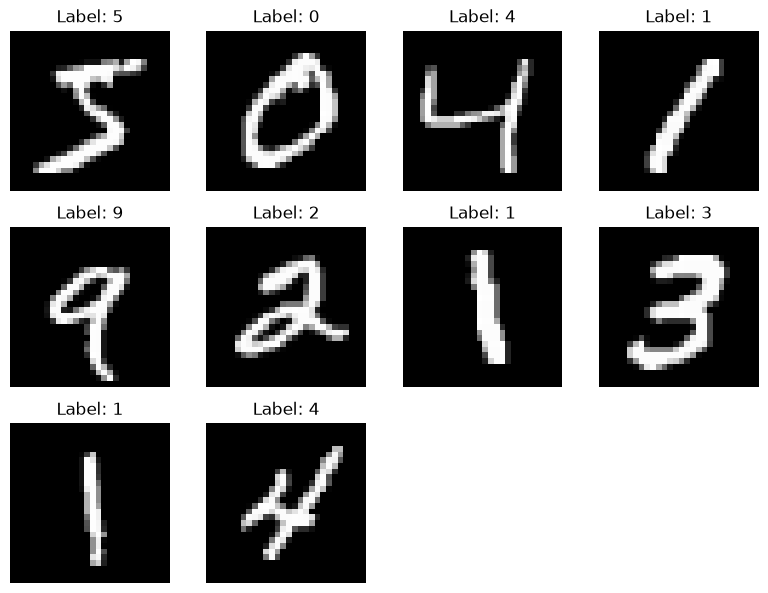

In [3]:
import matplotlib.pyplot as plt

def show_images(images, labels, rows=28, cols = 28, count=10):
    plt.figure(figsize=(8,8))
    
    for i in range(count):
        image_2D = [
            images[i][r * cols:(r+1) * cols]
            for r in range(rows)
        ]
        
        plt.subplot(4,4, i + 1)
        plt.imshow(image_2D, cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()
    
show_images(train_images, train_labels, rows=28, cols=28, count=10)

In [4]:
def reshape_images(image, rows = 28, cols = 28):
    return [
        image[i * cols:(i + 1) * cols]
        for i in range(rows)
    ]

In [5]:
train_images = [reshape_images(image, rows, cols) for image in train_images]
test_images = [reshape_images(image, rows, cols) for image in test_images]

In [6]:
print("number of training images:", len(train_images))
print("rows in first image:", len(train_images[0]))
print("cols in first image:", len(train_images[0][0]))
print("first pixel value:", train_images[0][0][0])

number of training images: 60000
rows in first image: 28
cols in first image: 28
first pixel value: 0.0


In [7]:
train_images_cnn = [
    [image] for image in train_images
]

test_images_cnn = [
    [image] for image in test_images
]



In [8]:
print(len(train_images_cnn[0]))
print(len(train_images_cnn[0][0]))
print(len(train_images_cnn[0][0][0]))

1
28
28


In [9]:
import random
import math

def init_filters(num_filters, channels, kernel_size):
    scale = math.sqrt(2 / (channels * kernel_size * kernel_size))
    
    filters = []
    
    for _ in range(num_filters):
        one_filter = []
        
        for _ in range(channels):
            channel_kernel = []
            
            for _ in range(kernel_size):
                row = [
                    random.uniform(-scale, scale)
                    for _ in range(kernel_size)
                ]
                channel_kernel.append(row)
            one_filter.append(channel_kernel)
        filters.append(one_filter)
        
    biases = [0.0 for _ in range(num_filters)]
    
    return filters, biases

In [10]:
filters, biases = init_filters(num_filters = 8, channels = 1, kernel_size = 3)

In [11]:
num_filters = len(filters)
print("Number of filters:", num_filters)
print("Filter shape:", len(filters[0]), "x", len(filters[0][0]), "x", len(filters[0][0][0]))
print("Bias shape:", len(biases))

Number of filters: 8
Filter shape: 1 x 3 x 3
Bias shape: 8


In [12]:
def conv_frwd(image, filters, biases, stride=1):
    channels = len(image)
    image_height = len(image[0])
    image_width = len(image[0][0])
    
    num_filters = len(filters)
    kernel_size = len(filters[0][0])
    
    output_height = ((image_height - kernel_size) // stride) + 1
    output_width = ((image_width - kernel_size) // stride) + 1
    
    output = []
    
    for f in range(num_filters):
        feature_map = []
        
        for i in range(output_height):
            row = []
            
            for j in range(output_width):
                total = 0.0
                
                for c in range(channels):
                    for ki in range(kernel_size):
                        for kj in range(kernel_size):
                            image_value = image[c][i * stride + ki][j * stride + kj]
                            filter_value = filters[f][c][ki][kj]
                            total += image_value * filter_value
                total += biases[f]
                row.append(total)
                
            feature_map.append(row)
            
        output.append(feature_map)
    return output

In [13]:
first_image = train_images_cnn[5]

conv_output = conv_frwd(first_image, filters, biases)

In [14]:
print(len(conv_output))
print(len(conv_output[0]))
print(len(conv_output[0][0]))

8
26
26


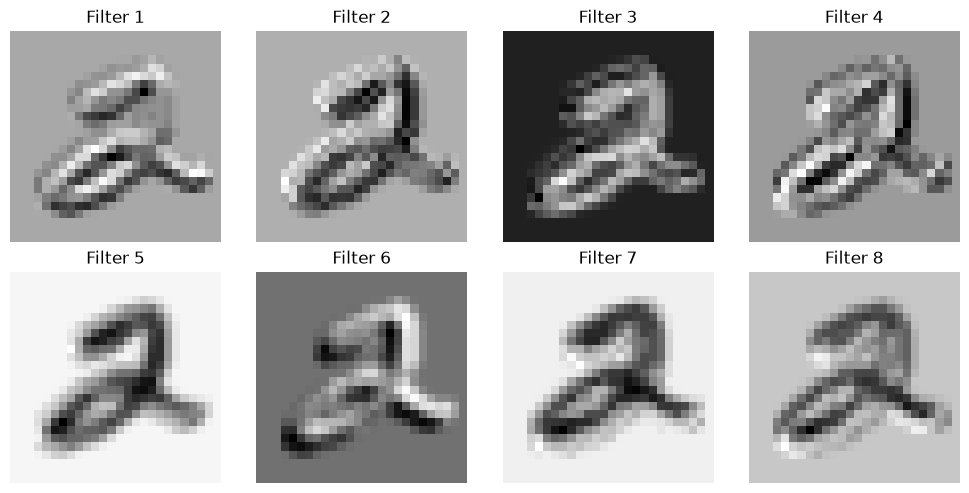

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(conv_output[i], cmap="gray")
    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
def relu(feature_maps):
    return [
        [
            [max(0, value) for value in row]
            for row in feature_map
        ]
        for feature_map in feature_maps
    ]
    
relu_output = relu(conv_output)

In [17]:
def max_pool(feature_maps, pool_size=2, stride=2):
    pooled_maps = []
    
    for feature_map in feature_maps:
        height = len(feature_map)
        width = len(feature_map[0])
        
        output_height = ((height - pool_size) // stride) + 1
        output_width = ((width - pool_size) // stride) + 1
        
        pooled_map = []
        
        for i in range(output_height):
            row = []
            
            for j in range(output_width):
                max_value = float('-inf')
                
                for pi in range(pool_size):
                    for pj in range(pool_size):
                        value = feature_map[i * stride + pi][j * stride + pj]
                        
                        if value > max_value:
                            max_value = value
                            
                row.append(max_value)
                
            pooled_map.append(row)
            
        pooled_maps.append(pooled_map)
        
    return pooled_maps

In [18]:
pool_output = max_pool(relu_output, pool_size=2, stride=2)

print(len(pool_output))          # 8 feature maps
print(len(pool_output[0]))       # 13 rows
print(len(pool_output[0][0]))    # 13 cols

8
13
13


In [19]:
def flatten(feature_maps):
    flat = []
    for feature_map in feature_maps:
        for row in feature_map:
            for value in row:
                flat.append(value)
    return flat

In [20]:
flat_output = flatten(pool_output)

print("Flattened size:", len(flat_output))

Flattened size: 1352


In [21]:
def init_dense(input_size, output_size):
    scale = math.sqrt(2 / input_size)
    
    weights = []
    
    for _ in range(output_size):
        row = [
            random.uniform(-scale, scale)
            for _ in range(input_size)
        ]
        weights.append(row)
        
    biases = [0.0 for _ in range(output_size)]
    
    return weights, biases

In [22]:
dense_weights, dense_biases = init_dense(
    input_size=len(flat_output),
    output_size=10
)

In [23]:
def dense_forward(inputs, weights, biases):
    outputs = []

    for neuron_index in range(len(weights)):
        total = biases[neuron_index]

        for i in range(len(inputs)):
            total += inputs[i] * weights[neuron_index][i]

        outputs.append(total)

    return outputs

In [24]:
def softmax(logits):
    max_logit = max(logits)
    exps = [math.exp(x - max_logit) for x in logits]
    total = sum(exps)
    return [x / total for x in exps]

In [25]:
def cross_entropy_loss(probabilities, correct_label):
    return -math.log(probabilities[correct_label] + 1e-9)

In [26]:
logits = dense_forward(flat_output, dense_weights, dense_biases)
probabilities = softmax(logits)

label = train_labels[5]
loss = cross_entropy_loss(probabilities, label)

print("Probabilities:", probabilities)
print("Predicted digit:", probabilities.index(max(probabilities)))
print("Actual digit:", label)
print("Loss:", loss)

Probabilities: [0.09815230210833616, 0.08925290887595083, 0.08839016484281209, 0.07678027329330049, 0.11409282304643469, 0.11916999312814841, 0.1071021621530656, 0.11136120281735173, 0.10896106429876508, 0.08673710543583499]
Predicted digit: 5
Actual digit: 2
Loss: 2.425994561648883


In [27]:
for digit, prob in enumerate(probabilities):
    print(digit, round(prob, 4))

0 0.0982
1 0.0893
2 0.0884
3 0.0768
4 0.1141
5 0.1192
6 0.1071
7 0.1114
8 0.109
9 0.0867


In [28]:
def softmax_cross_entropy_backward(probabilities, correct_label):
    gradients = probabilities[:]
    gradients[correct_label] -= 1
    return gradients

In [29]:
d_logits = softmax_cross_entropy_backward(probabilities, label)

print(d_logits)

[0.09815230210833616, 0.08925290887595083, -0.911609835157188, 0.07678027329330049, 0.11409282304643469, 0.11916999312814841, 0.1071021621530656, 0.11136120281735173, 0.10896106429876508, 0.08673710543583499]


In [30]:
def dense_backward(inputs, weights, d_outputs):
    d_inputs = [0.0 for _ in range(len(inputs))]
    d_weights = []
    d_biases = d_outputs[:]
    
    for neuron_index in range(len(weights)):
        weight_gradients = []
        
        for i in range(len(inputs)):
            weight_gradients.append(d_outputs[neuron_index] * inputs[i])
            d_inputs[i] += d_outputs[neuron_index] * weights[neuron_index][i]
        d_weights.append(weight_gradients)
    return d_inputs, d_weights, d_biases

In [31]:
d_flat_output, d_dense_weights, d_dense_biases = dense_backward(
    flat_output,
    dense_weights,
    d_logits
)

print(len(d_flat_output))          # 1352
print(len(d_dense_weights))        # 10
print(len(d_dense_weights[0]))     # 1352
print(len(d_dense_biases))         # 10

1352
10
1352
10


In [32]:
def update_dense(weights, biases, d_weights, d_biases, learning_rate):
    for neuron_index in range(len(weights)):
        for i in range(len(weights[neuron_index])):
            weights[neuron_index][i] -= learning_rate * d_weights[neuron_index][i]

        biases[neuron_index] -= learning_rate * d_biases[neuron_index]

In [33]:
update_dense(
    dense_weights,
    dense_biases,
    d_dense_weights,
    d_dense_biases,
    learning_rate=0.01
)

In [34]:
new_logits = dense_forward(flat_output, dense_weights, dense_biases)
new_probabilities = softmax(new_logits)
new_loss = cross_entropy_loss(new_probabilities, label)

print("Old prediction:", probabilities.index(max(probabilities)))
print("New prediction:", new_probabilities.index(max(new_probabilities)))

print("Old loss:", loss)
print("New loss:", new_loss)

for digit, prob in enumerate(new_probabilities):
    print(digit, round(prob, 4))

Old prediction: 5
New prediction: 2
Old loss: 2.425994561648883
New loss: 2.1119756457227536
0 0.0948
1 0.0865
2 0.121
3 0.0747
4 0.1096
5 0.1143
6 0.1031
7 0.1071
8 0.1048
9 0.0841


In [35]:
def flatten_backward(d_flat, original_shape):
    channels, height, width = original_shape

    d_feature_maps = []
    index = 0

    for c in range(channels):
        feature_map = []

        for i in range(height):
            row = []

            for j in range(width):
                row.append(d_flat[index])
                index += 1

            feature_map.append(row)

        d_feature_maps.append(feature_map)

    return d_feature_maps

In [36]:
d_pool_output = flatten_backward(
    d_flat_output,
    original_shape=(8, 13, 13)
)

print(len(d_pool_output))          # 8
print(len(d_pool_output[0]))       # 13
print(len(d_pool_output[0][0]))    # 13

8
13
13


In [37]:
def max_pool_backward(d_pooled_maps, original_feature_maps, pool_size=2, stride=2):
    d_feature_maps = []

    for fmap_index in range(len(original_feature_maps)):
        feature_map = original_feature_maps[fmap_index]

        height = len(feature_map)
        width = len(feature_map[0])

        d_feature_map = [
            [0.0 for _ in range(width)]
            for _ in range(height)
        ]

        pooled_height = len(d_pooled_maps[fmap_index])
        pooled_width = len(d_pooled_maps[fmap_index][0])

        for i in range(pooled_height):
            for j in range(pooled_width):
                max_value = float("-inf")
                max_i = 0
                max_j = 0

                for pi in range(pool_size):
                    for pj in range(pool_size):
                        row = i * stride + pi
                        col = j * stride + pj

                        value = feature_map[row][col]

                        if value > max_value:
                            max_value = value
                            max_i = row
                            max_j = col

                d_feature_map[max_i][max_j] += d_pooled_maps[fmap_index][i][j]

        d_feature_maps.append(d_feature_map)

    return d_feature_maps

In [38]:
d_relu_output = max_pool_backward(
    d_pool_output,
    relu_output,
    pool_size=2,
    stride=2
)

print(len(d_relu_output))          # 8
print(len(d_relu_output[0]))       # 26
print(len(d_relu_output[0][0]))    # 26

8
26
26


In [39]:
def relu_backward(d_output, original_input):
    d_input = []

    for fmap_index in range(len(original_input)):
        d_feature_map = []

        for i in range(len(original_input[fmap_index])):
            row = []

            for j in range(len(original_input[fmap_index][i])):
                if original_input[fmap_index][i][j] > 0:
                    row.append(d_output[fmap_index][i][j])
                else:
                    row.append(0.0)

            d_feature_map.append(row)

        d_input.append(d_feature_map)

    return d_input

In [40]:
d_conv_output = relu_backward(
    d_relu_output,
    conv_output
)

print(len(d_conv_output))          # 8
print(len(d_conv_output[0]))       # 26
print(len(d_conv_output[0][0]))    # 26

8
26
26


In [41]:
def conv_backward(image, filters, d_output, stride=1):
    channels = len(image)
    image_height = len(image[0])
    image_width = len(image[0][0])

    num_filters = len(filters)
    kernel_size = len(filters[0][0])

    d_image = [
        [
            [0.0 for _ in range(image_width)]
            for _ in range(image_height)
        ]
        for _ in range(channels)
    ]

    d_filters = [
        [
            [
                [0.0 for _ in range(kernel_size)]
                for _ in range(kernel_size)
            ]
            for _ in range(channels)
        ]
        for _ in range(num_filters)
    ]

    d_biases = [0.0 for _ in range(num_filters)]

    output_height = len(d_output[0])
    output_width = len(d_output[0][0])

    for f in range(num_filters):
        for i in range(output_height):
            for j in range(output_width):
                grad = d_output[f][i][j]
                d_biases[f] += grad

                for c in range(channels):
                    for ki in range(kernel_size):
                        for kj in range(kernel_size):
                            image_row = i * stride + ki
                            image_col = j * stride + kj

                            d_filters[f][c][ki][kj] += image[c][image_row][image_col] * grad
                            d_image[c][image_row][image_col] += filters[f][c][ki][kj] * grad

    return d_image, d_filters, d_biases

In [42]:
d_image, d_filters, d_conv_biases = conv_backward(
    first_image,
    filters,
    d_conv_output,
    stride=1
)

print(len(d_image))                # 1
print(len(d_image[0]))             # 28
print(len(d_image[0][0]))          # 28

print(len(d_filters))              # 8
print(len(d_filters[0]))           # 1
print(len(d_filters[0][0]))        # 3
print(len(d_filters[0][0][0]))     # 3

print(len(d_conv_biases))          # 8

1
28
28
8
1
3
3
8


In [43]:
def update_conv(filters, biases, d_filters, d_biases, learning_rate):
    for f in range(len(filters)):
        for c in range(len(filters[f])):
            for i in range(len(filters[f][c])):
                for j in range(len(filters[f][c][i])):
                    filters[f][c][i][j] -= learning_rate * d_filters[f][c][i][j]

        biases[f] -= learning_rate * d_biases[f]

In [44]:
update_conv(
    filters,
    biases,
    d_filters,
    d_conv_biases,
    learning_rate=0.01
)

In [45]:
conv_output_2 = conv_frwd(first_image, filters, biases)
relu_output_2 = relu(conv_output_2)
pool_output_2 = max_pool(relu_output_2, pool_size=2, stride=2)
flat_output_2 = flatten(pool_output_2)

logits_2 = dense_forward(flat_output_2, dense_weights, dense_biases)
probabilities_2 = softmax(logits_2)
loss_2 = cross_entropy_loss(probabilities_2, label)

print("Prediction after full update:", probabilities_2.index(max(probabilities_2)))
print("Actual:", label)
print("Loss after full update:", loss_2)

for digit, prob in enumerate(probabilities_2):
    print(digit, round(prob, 4))

Prediction after full update: 2
Actual: 2
Loss after full update: 2.109599099450398
0 0.0948
1 0.0865
2 0.1213
3 0.0749
4 0.1095
5 0.1139
6 0.1028
7 0.1074
8 0.1047
9 0.0843


In [46]:
def train_one_image(image, label, filters, biases, dense_weights, dense_biases, learning_rate=0.01):
    # forward pass
    conv_output = conv_frwd(image, filters, biases)
    relu_output = relu(conv_output)
    pool_output = max_pool(relu_output, pool_size=2, stride=2)
    flat_output = flatten(pool_output)

    logits = dense_forward(flat_output, dense_weights, dense_biases)
    probabilities = softmax(logits)
    loss = cross_entropy_loss(probabilities, label)

    prediction = probabilities.index(max(probabilities))

    # backward pass
    d_logits = softmax_cross_entropy_backward(probabilities, label)

    d_flat_output, d_dense_weights, d_dense_biases = dense_backward(
        flat_output,
        dense_weights,
        d_logits
    )

    d_pool_output = flatten_backward(
        d_flat_output,
        original_shape=(len(pool_output), len(pool_output[0]), len(pool_output[0][0]))
    )

    d_relu_output = max_pool_backward(
        d_pool_output,
        relu_output,
        pool_size=2,
        stride=2
    )

    d_conv_output = relu_backward(
        d_relu_output,
        conv_output
    )

    d_image, d_filters, d_conv_biases = conv_backward(
        image,
        filters,
        d_conv_output,
        stride=1
    )

    # update weights after all gradients are calculated
    update_dense(
        dense_weights,
        dense_biases,
        d_dense_weights,
        d_dense_biases,
        learning_rate
    )

    update_conv(
        filters,
        biases,
        d_filters,
        d_conv_biases,
        learning_rate
    )

    return loss, prediction

In [47]:
loss, prediction = train_one_image(
    train_images_cnn[5],
    train_labels[5],
    filters,
    biases,
    dense_weights,
    dense_biases,
    learning_rate=0.01
)

print("Loss:", loss)
print("Prediction:", prediction)
print("Actual:", train_labels[5])

Loss: 2.109599099450398
Prediction: 2
Actual: 2


In [48]:
def train(images, labels, filters, biases, dense_weights, dense_biases, epochs=1, learning_rate=0.01, limit=100):
    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0

        for i in range(limit):
            loss, prediction = train_one_image(
                images[i],
                labels[i],
                filters,
                biases,
                dense_weights,
                dense_biases,
                learning_rate
            )

            total_loss += loss

            if prediction == labels[i]:
                correct += 1

        avg_loss = total_loss / limit
        accuracy = correct / limit

        print(f"Epoch: {epoch + 1}", f"Average loss: {avg_loss:.4f}", f"Accuracy: {accuracy:.4f}")

In [49]:
train(
    train_images_cnn,
    train_labels,
    filters,
    biases,
    dense_weights,
    dense_biases,
    epochs=3,
    learning_rate=0.005,
    limit=100
)

Epoch: 1 Average loss: 2.2181 Accuracy: 0.2200
Epoch: 2 Average loss: 1.8557 Accuracy: 0.5800
Epoch: 3 Average loss: 1.3318 Accuracy: 0.7400


In [50]:
def predict_one_image(image, label, filters, biases, dense_weights, dense_biases):
    conv_output = conv_frwd(image, filters, biases)
    relu_output = relu(conv_output)
    pool_output = max_pool(relu_output, pool_size=2, stride=2)
    flat_output = flatten(pool_output)

    logits = dense_forward(flat_output, dense_weights, dense_biases)
    probabilities = softmax(logits)
    loss = cross_entropy_loss(probabilities, label)

    prediction = probabilities.index(max(probabilities))

    return loss, prediction, probabilities

In [51]:
def evaluate(images, labels, filters, biases, dense_weights, dense_biases, limit=100):
    total_loss = 0.0
    correct = 0

    for i in range(limit):
        loss, prediction, probabilities = predict_one_image(
            images[i],
            labels[i],
            filters,
            biases,
            dense_weights,
            dense_biases
        )

        total_loss += loss

        if prediction == labels[i]:
            correct += 1

    avg_loss = total_loss / limit
    accuracy = correct / limit

    print(f"Evaluation loss: {avg_loss:.4f}", f"Accuracy: {accuracy:.4f}")

In [52]:
evaluate(
    test_images_cnn,
    test_labels,
    filters,
    biases,
    dense_weights,
    dense_biases,
    limit=100
)

Evaluation loss: 1.3190 Accuracy: 0.6400


In [53]:
def train_random(images, labels, filters, biases, dense_weights, dense_biases, epochs=1, learning_rate=0.003, limit=500):
    indices = list(range(len(images)))

    for epoch in range(epochs):
        random.shuffle(indices)

        total_loss = 0.0
        correct = 0

        for step in range(limit):
            i = indices[step]

            loss, prediction = train_one_image(
                images[i],
                labels[i],
                filters,
                biases,
                dense_weights,
                dense_biases,
                learning_rate
            )

            total_loss += loss

            if prediction == labels[i]:
                correct += 1

        print(f"Epoch: {epoch + 1}", f"Average loss: {total_loss / limit:.4f}", f"Accuracy: {correct / limit:.4f}")

In [54]:
train_random(
    train_images_cnn,
    train_labels,
    filters,
    biases,
    dense_weights,
    dense_biases,
    epochs=3,
    learning_rate=0.003,
    limit=1000
)

Epoch: 1 Average loss: 0.7737 Accuracy: 0.7800
Epoch: 2 Average loss: 0.4902 Accuracy: 0.8620
Epoch: 3 Average loss: 0.4555 Accuracy: 0.8590


In [55]:
evaluate(
    test_images_cnn,
    test_labels,
    filters,
    biases,
    dense_weights,
    dense_biases,
    limit=1000
)

Evaluation loss: 0.5334 Accuracy: 0.8310
